# Portfolio Optimization & Risk Analysis
### A guided, run-as-you-go notebook — every step explained before you run it

Read the markdown cell above each code cell before running it. Run cells **top to bottom, one at a time** (Shift+Enter) — don't skip ahead, since later cells depend on variables created earlier ones.

**Before running anything in this notebook**, open a terminal and install the required packages:
```
pip install pandas numpy matplotlib yfinance scipy
```
Then come back here and run the cells below.


## Part 1 — Imports

We load our tools first. `pandas` handles tables, `numpy` handles fast math, `matplotlib` handles charts, `yfinance` pulls free stock data, `scipy` will later help us find the mathematically optimal portfolio.

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

print("Libraries loaded successfully.")


Libraries loaded successfully.


## Part 2 — Pick your stocks and download price history

Change the `tickers` list below to whatever stocks you want to analyze. `.NS` is the suffix for NSE (India)-listed stocks — for US stocks just use the plain symbol (e.g. `"AAPL"`).

We're downloading 5 years of daily **closing prices** — closing price is the standard, comparable snapshot of a stock's value used in portfolio math.

In [3]:
tickers = ["RELIANCE.NS", "TCS.NS", "HDFCBANK.NS", "INFY.NS", "ITC.NS"]

data = yf.download(tickers, start="2020-01-01", end="2025-01-01")["Close"]
data.head()


[*********************100%***********************]  5 of 5 completed


Ticker,HDFCBANK.NS,INFY.NS,ITC.NS,RELIANCE.NS,TCS.NS
Date,,,,,
2020-01-01,595.677185,619.740295,168.796631,672.216187,1831.109863
2020-01-02,599.474121,617.932068,170.037247,683.660278,1822.704468
2020-01-03,590.925232,627.436157,169.080215,684.484131,1859.029053
2020-01-06,578.136719,621.422363,166.669846,668.609314,1858.859741
2020-01-07,587.291321,612.212646,166.847061,678.895691,1863.421997


**Check:** the table above should show 5 columns (one per stock) and dates as the row index, with no obvious gaps or all-`NaN` columns. If a column is empty, double check that ticker symbol is correct.

## Part 3 — Convert prices into returns

We can't compare stocks by raw price (₹2,500 vs ₹450 tells you nothing about performance). We convert to **daily % returns**, which is what all the math from here forward is built on.

`.pct_change()` computes `(today - yesterday) / yesterday` for every column at once. `.dropna()` removes the first row, which has no "yesterday" to compare to.

In [4]:
returns = data.pct_change().dropna()
returns.head()


Ticker,HDFCBANK.NS,INFY.NS,ITC.NS,RELIANCE.NS,TCS.NS
Date,,,,,
2020-01-02,0.006374,-0.002918,0.007350,0.017024,-0.004590
2020-01-03,-0.014261,0.015380,-0.005628,0.001205,0.019929
2020-01-06,-0.021642,-0.009585,-0.014256,-0.023192,-0.000091
2020-01-07,0.015835,-0.014820,0.001063,0.015385,0.002454
2020-01-08,-0.002618,-0.013326,-0.004886,-0.007510,0.022395


## Part 4 — Core statistics: average return, and how stocks move together

- `mean_returns`: each stock's average daily return.
- `cov_matrix`: the **covariance matrix** — for every pair of stocks, how much they tend to move together. This is the piece that makes this *portfolio* theory rather than just stock-picking: two stocks that move together give you little diversification benefit; two that move independently (or oppositely) smooth out your overall ride.

We then **annualize** both (multiply by 252, the standard number of trading days per year) since daily numbers are too small to interpret intuitively.

In [5]:
mean_returns = returns.mean()
cov_matrix = returns.cov()

trading_days = 252
annual_mean_returns = mean_returns * trading_days
annual_cov_matrix = cov_matrix * trading_days

print("Annualized expected returns:")
print(annual_mean_returns)


Annualized expected returns:
Ticker
HDFCBANK.NS    0.112183
INFY.NS        0.254619
ITC.NS         0.223851
RELIANCE.NS    0.162979
TCS.NS         0.179412
dtype: float64


## Part 5 — Monte Carlo Simulation: generate 10,000 random portfolios

We can't test every possible way to split money across these stocks (infinite combinations), so we **randomly generate thousands of weight combinations** and measure each one's return, risk, and Sharpe Ratio. This is called a Monte Carlo Simulation.

For each simulated portfolio we compute:
1. **Return** — weighted average of each stock's return
2. **Risk (volatility)** — uses the covariance matrix, not just a simple average, because diversification depends on how stocks move *together*
3. **Sharpe Ratio** — `(return - risk_free_rate) / risk` → return earned *per unit of risk taken*, above what you'd earn risk-free

Adjust `risk_free_rate` to a current approximate risk-free rate (e.g. a T-bill yield) if you want it more accurate.

In [6]:
num_portfolios = 10000
num_assets = len(tickers)
risk_free_rate = 0.07

results = np.zeros((3, num_portfolios))
weights_record = []

for i in range(num_portfolios):
    weights = np.random.random(num_assets)
    weights /= np.sum(weights)          # force weights to sum to 100%
    weights_record.append(weights)

    port_return = np.dot(weights, annual_mean_returns)
    port_variance = np.dot(weights.T, np.dot(annual_cov_matrix, weights))
    port_std = np.sqrt(port_variance)
    sharpe_ratio = (port_return - risk_free_rate) / port_std

    results[0, i] = port_return
    results[1, i] = port_std
    results[2, i] = sharpe_ratio

print("Simulation complete. Example — first simulated portfolio's weights:")
print(dict(zip(tickers, weights_record[0].round(3))))


Simulation complete. Example — first simulated portfolio's weights:
{'RELIANCE.NS': np.float64(0.309), 'TCS.NS': np.float64(0.151), 'HDFCBANK.NS': np.float64(0.324), 'INFY.NS': np.float64(0.035), 'ITC.NS': np.float64(0.18)}


## Part 6 — Find the mathematically optimal portfolio (not just the best random guess)

10,000 random guesses gets us *close* to the best portfolio, but an **optimizer** can find the actual best one directly. `scipy.optimize.minimize` searches for the input that minimizes a function's output — since we want to *maximize* Sharpe Ratio, we minimize *negative* Sharpe (a standard trick).

Constraints: weights must sum to 100% (`eq` constraint), and each weight is bounded between 0% and 100% (no short-selling).

In [7]:
def portfolio_performance(weights, mean_returns, cov_matrix):
    ret = np.dot(weights, mean_returns)
    std = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    return ret, std

def negative_sharpe(weights, mean_returns, cov_matrix, risk_free_rate):
    ret, std = portfolio_performance(weights, mean_returns, cov_matrix)
    return -(ret - risk_free_rate) / std

constraints = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1})
bounds = tuple((0, 1) for _ in range(num_assets))
initial_guess = num_assets * [1. / num_assets]

optimal = minimize(negative_sharpe, initial_guess,
                    args=(annual_mean_returns, annual_cov_matrix, risk_free_rate),
                    method='SLSQP', bounds=bounds, constraints=constraints)

optimal_weights = optimal.x
print("Optimal weights:")
for t, w in zip(tickers, optimal_weights):
    print(f"  {t}: {w:.2%}")


Optimal weights:
  RELIANCE.NS: 0.00%
  TCS.NS: 52.64%
  HDFCBANK.NS: 47.36%
  INFY.NS: 0.00%
  ITC.NS: 0.00%


## Part 7 — Risk metrics: Beta, Value at Risk (VaR), Max Drawdown

Three different questions, three different metrics:
- **Beta**: how much does my portfolio move relative to the overall market?
- **VaR**: what's my worst *plausible* daily loss, at a given confidence level?
- **Max Drawdown**: what's the worst peak-to-trough decline I would have lived through historically?

First, we combine the individual stock returns into a single **portfolio return series**, using the optimal weights we just solved for.

In [8]:
portfolio_returns = returns.dot(optimal_weights)
portfolio_returns.head()


Date
2020-01-02    0.001945
2020-01-03    0.005431
2020-01-06   -0.011797
2020-01-07   -0.007298
2020-01-08   -0.009329
dtype: float64

### 7.1 — Beta (vs. the Nifty 50 index)

Beta = 1 → moves exactly with the market. Beta > 1 → amplifies market moves. Beta < 1 → more defensive than the market.

In [9]:
market = yf.download("^NSEI", start="2020-01-01", end="2025-01-01")["Close"]
market_returns = market.pct_change().dropna()

aligned = pd.concat([portfolio_returns, market_returns], axis=1).dropna()
aligned.columns = ["portfolio", "market"]

covariance = aligned["portfolio"].cov(aligned["market"])
market_variance = aligned["market"].var()
beta = covariance / market_variance

print(f"Portfolio Beta: {beta:.2f}")


[*********************100%***********************]  1 of 1 completed

Portfolio Beta: 0.79


### 7.2 — Value at Risk (95% confidence, historical method)

Reads as: "there's a 95% chance the portfolio won't lose more than X% tomorrow — but a 5% chance it could lose more than that." This method (`np.percentile`) sorts historical daily returns and finds the value only 5% of days fell below.

In [10]:
confidence_level = 0.95
VaR_95 = np.percentile(portfolio_returns, (1 - confidence_level) * 100)
print(f"95% daily VaR: {VaR_95:.2%}")


95% daily VaR: -1.77%


### 7.3 — Max Drawdown

Tracks a running cumulative growth line, compares it to its running peak, and finds the single worst decline from any peak to the lowest point after it. Captures the "worst pain" an investor would have lived through, which volatility alone doesn't show.

In [11]:
cumulative = (1 + portfolio_returns).cumprod()
running_max = cumulative.cummax()
drawdown = (cumulative - running_max) / running_max
max_drawdown = drawdown.min()

print(f"Max Drawdown: {max_drawdown:.2%}")


Max Drawdown: -34.22%


## Part 8 — Visualize it

### 8.1 Optimal allocation pie chart

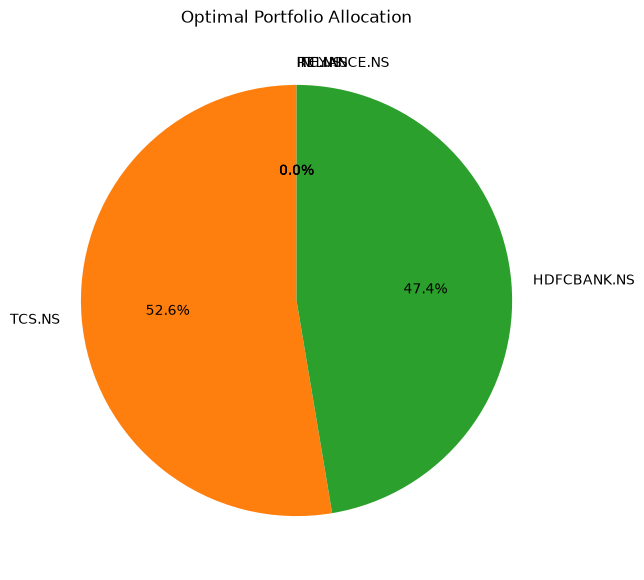

In [12]:
plt.figure(figsize=(7, 7))
plt.pie(optimal_weights, labels=tickers, autopct='%1.1f%%', startangle=90)
plt.title("Optimal Portfolio Allocation")
plt.show()


### 8.2 The efficient frontier

Every dot is one simulated portfolio: x = risk, y = return, color = Sharpe Ratio. The upper-left edge of the cloud is the "efficient frontier" — the red star (our optimizer's answer) should sit right on it.

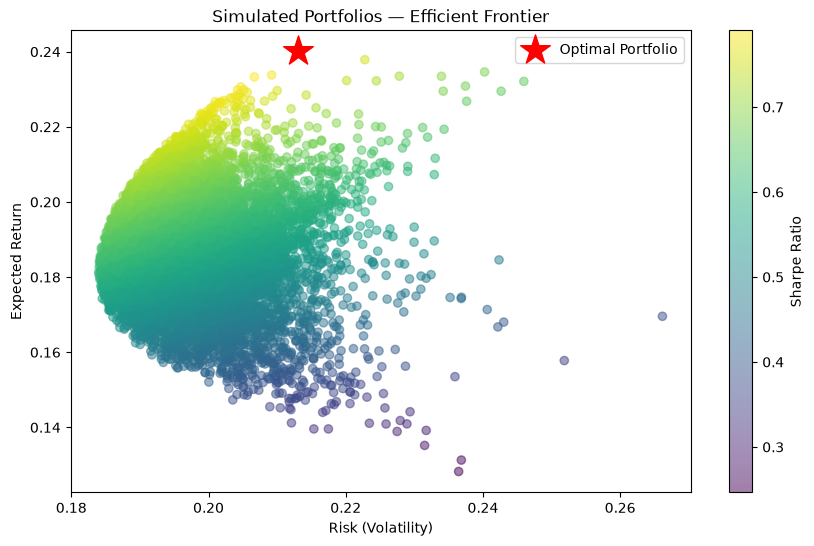

In [13]:
plt.figure(figsize=(10, 6))
plt.scatter(results[1], results[0], c=results[2], cmap='viridis', alpha=0.5)
plt.colorbar(label='Sharpe Ratio')
plt.xlabel('Risk (Volatility)')
plt.ylabel('Expected Return')
plt.title('Simulated Portfolios — Efficient Frontier')

opt_ret, opt_std = portfolio_performance(optimal_weights, annual_mean_returns, annual_cov_matrix)
plt.scatter(opt_std, opt_ret, c='red', marker='*', s=500, label='Optimal Portfolio')
plt.legend()
plt.show()


## Part 9 — Summary 

In [14]:
print("=== PORTFOLIO SUMMARY ===")
print("Optimal Weights:")
for t, w in zip(tickers, optimal_weights):
    print(f"  {t}: {w:.2%}")
print(f"\nExpected Annual Return: {opt_ret:.2%}")
print(f"Annual Volatility (Risk): {opt_std:.2%}")
print(f"Sharpe Ratio: {(opt_ret - risk_free_rate) / opt_std:.2f}")
print(f"Beta (vs Nifty 50): {beta:.2f}")
print(f"95% Daily VaR: {VaR_95:.2%}")
print(f"Max Drawdown: {max_drawdown:.2%}")


=== PORTFOLIO SUMMARY ===
Optimal Weights:
  RELIANCE.NS: 0.00%
  TCS.NS: 52.64%
  HDFCBANK.NS: 47.36%
  INFY.NS: 0.00%
  ITC.NS: 0.00%

Expected Annual Return: 24.00%
Annual Volatility (Risk): 21.31%
Sharpe Ratio: 0.80
Beta (vs Nifty 50): 0.79
95% Daily VaR: -1.77%
Max Drawdown: -34.22%
